In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: cpu


In [2]:
from pathlib import Path
import cdsapi

download_path = Path("./downloads/era5")
download_path.mkdir(parents=True, exist_ok=True)

c = cdsapi.Client()

# Static
static_file = download_path / "static.nc"
if not static_file.exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": ["geopotential", "land_sea_mask", "soil_type"],
            "year": "2023",
            "month": "01",
            "day": "01",
            "time": "00:00",
            "format": "netcdf",
        },
        str(static_file),
    )
print("Static variables downloaded!")

# Surface (4 times only)
surf_file = download_path / "2023-01-01-surface-level.nc"
if not surf_file.exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "2m_temperature",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "mean_sea_level_pressure",
            ],
            "year": "2023",
            "month": "01",
            "day": "01",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "format": "netcdf",
        },
        str(surf_file),
    )
print("Surface-level variables downloaded!")

# Pressure levels (4 times only)
atm_file = download_path / "2023-01-01-atmospheric.nc"
if not atm_file.exists():
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "temperature",
                "u_component_of_wind",
                "v_component_of_wind",
                "specific_humidity",
                "geopotential",
            ],
            "pressure_level": ["50","100","150","200","250","300","400","500","600","700","850","925","1000"],
            "year": "2023",
            "month": "01",
            "day": "01",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "format": "netcdf",
        },
        str(atm_file),
    )
print("Atmospheric variables downloaded!")


2025-12-17 00:10:55,851 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


Static variables downloaded!
Surface-level variables downloaded!
Atmospheric variables downloaded!


In [4]:
import xarray as xr
import torch
from aurora import Batch, Metadata

static_vars_ds = xr.open_dataset(static_file, engine="netcdf4")
surf_vars_ds   = xr.open_dataset(surf_file, engine="netcdf4")
atmos_vars_ds  = xr.open_dataset(atm_file, engine="netcdf4")

batch = Batch(
    surf_vars={
        "2t":  torch.from_numpy(surf_vars_ds["t2m"].values[:2][None]),
        "10u": torch.from_numpy(surf_vars_ds["u10"].values[:2][None]),
        "10v": torch.from_numpy(surf_vars_ds["v10"].values[:2][None]),
        "msl": torch.from_numpy(surf_vars_ds["msl"].values[:2][None]),
    },
    static_vars={
        "z":   torch.from_numpy(static_vars_ds["z"].values[0]),
        "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
        "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
    },
    atmos_vars={
        "t": torch.from_numpy(atmos_vars_ds["t"].values[:2][None]),
        "u": torch.from_numpy(atmos_vars_ds["u"].values[:2][None]),
        "v": torch.from_numpy(atmos_vars_ds["v"].values[:2][None]),
        "q": torch.from_numpy(atmos_vars_ds["q"].values[:2][None]),
        "z": torch.from_numpy(atmos_vars_ds["z"].values[:2][None]),
    },
    metadata=Metadata(
        lat=torch.from_numpy(surf_vars_ds.latitude.values),
        lon=torch.from_numpy(surf_vars_ds.longitude.values),
        time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
        atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
    ),
)


## Loading and Running the Model

Finally, we are ready to load and run the model and visualise the predictions. We perform a roll-out for two steps, which produces predictions for hours 12:00 and 18:00.

In [ ]:
from aurora import AuroraSmallPretrained, rollout

model = AuroraSmallPretrained(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-small-pretrained.ckpt")

model.eval()
model = model.to(device)

with torch.inference_mode():
    preds = [pred.to("cpu") for pred in rollout(model, batch, steps=2)]

print("Got", len(preds), "prediction steps.")


Got 2 prediction steps.


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))

for i in range(2):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction")
    ax[i, 0].set_xticks([]); ax[i, 0].set_yticks([])

    ax[i, 1].imshow(surf_vars_ds["t2m"][2 + i].values - 273.15, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("ERA5")
    ax[i, 1].set_xticks([]); ax[i, 1].set_yticks([])

plt.tight_layout()
plt.show()


# now let's try to add precipitation

In [5]:
from pathlib import Path
import cdsapi

download_path = Path("./downloads/era5")
download_path.mkdir(parents=True, exist_ok=True)

c = cdsapi.Client()

tp_file = download_path / "2023-01-01-tp-hourly-01_to_06.nc"
if not tp_file.exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": ["total_precipitation"],
            "year": "2023",
            "month": "01",
            "day": "01",
            "time": [f"{h:02d}:00" for h in range(1, 7)],  # 01..06 inclusive
            "format": "netcdf",
        },
        str(tp_file),
    )

print("TP hourly file:", tp_file)


2025-12-17 00:11:14,385 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


TP hourly file: downloads/era5/2023-01-01-tp-hourly-01_to_06.nc


In [6]:
import xarray as xr
import numpy as np

tp_ds = xr.open_dataset(tp_file, engine="netcdf4")
tp_hourly = tp_ds["tp"]  # dims: ('valid_time','latitude','longitude')

tp6h_ending_06 = tp_hourly.sum(dim="valid_time")   # <-- fix here
y = np.log1p(tp6h_ending_06)

print("tp_hourly dims:", tp_hourly.dims)
print("tp_hourly times:", tp_hourly["valid_time"].values)
print("tp6h_ending_06 shape:", tp6h_ending_06.shape)
print("tp6h stats (meters):", float(tp6h_ending_06.min()), float(tp6h_ending_06.mean()), float(tp6h_ending_06.max()))
print("log1p stats:", float(y.min()), float(y.mean()), float(y.max()))


tp_hourly dims: ('valid_time', 'latitude', 'longitude')
tp_hourly times: ['2023-01-01T01:00:00.000000000' '2023-01-01T02:00:00.000000000'
 '2023-01-01T03:00:00.000000000' '2023-01-01T04:00:00.000000000'
 '2023-01-01T05:00:00.000000000' '2023-01-01T06:00:00.000000000']
tp6h_ending_06 shape: (721, 1440)
tp6h stats (meters): 0.0 0.0005518487305380404 0.14329195022583008
log1p stats: 0.0 0.0005497062811627984 0.13391177356243134


In [7]:
tp6h_mm = tp6h_ending_06 * 1000.0
print("tp6h mean (mm):", float(tp6h_mm.mean()))
print("tp6h max  (mm):", float(tp6h_mm.max()))


tp6h mean (mm): 0.5518486499786377
tp6h max  (mm): 143.2919464111328


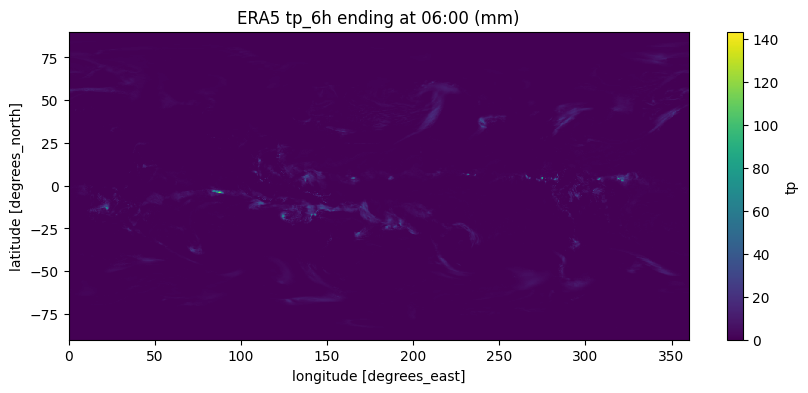

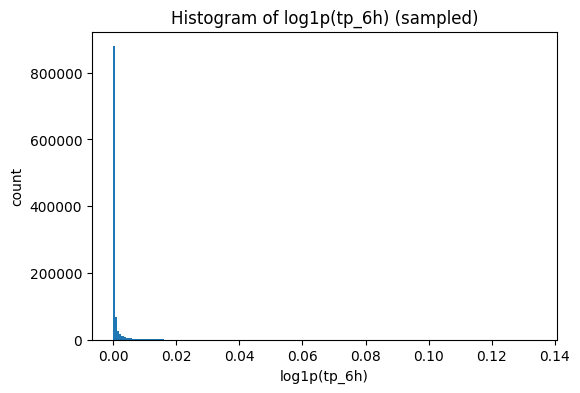

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
tp6h_mm.plot()
plt.title("ERA5 tp_6h ending at 06:00 (mm)")
plt.show()

vals = y.values.ravel()
vals = vals[~np.isnan(vals)]
if vals.size > 2_000_000:
    vals = np.random.choice(vals, size=2_000_000, replace=False)

plt.figure(figsize=(6,4))
plt.hist(vals, bins=200)
plt.title("Histogram of log1p(tp_6h) (sampled)")
plt.xlabel("log1p(tp_6h)")
plt.ylabel("count")
plt.show()


# step 3: Computing normalization stats

In [9]:
import numpy as np

vals = y.values.ravel()
vals = vals[~np.isnan(vals)]


In [10]:
mu_tp = float(vals.mean())
std_tp = float(vals.std())
eps = 1e-6
std_tp = max(std_tp, eps)


In [11]:
print(mu_tp)
print(std_tp)

0.0005497062811627984
0.0019855170976370573


In [12]:
#save them
import json

stats = {
    "target": "log1p_tp_6h",
    "mean": mu_tp,
    "std": std_tp,
    "units": "log(1 + meters)",
}

with open("tp_normalization.json", "w") as f:
    json.dump(stats, f, indent=2)


In [14]:
from aurora import AuroraSmallPretrained
model = AuroraSmallPretrained(use_lora=False)
print(model)


AuroraSmallPretrained(
  (encoder): Perceiver3DEncoder(
    (surf_mlp): MLP(
      (net): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1024, out_features=256, bias=True)
        (3): Dropout(p=0.0, inplace=False)
      )
    )
    (surf_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (pos_embed): Linear(in_features=256, out_features=256, bias=True)
    (scale_embed): Linear(in_features=256, out_features=256, bias=True)
    (lead_time_embed): Linear(in_features=256, out_features=256, bias=True)
    (absolute_time_embed): Linear(in_features=256, out_features=256, bias=True)
    (atmos_levels_embed): Linear(in_features=256, out_features=256, bias=True)
    (surf_token_embeds): LevelPatchEmbed(
      (weights): ParameterDict(
          (10u): Parameter containing: [torch.FloatTensor of size 256x1x2x4x4]
          (10v): Parameter containing: [torch.FloatTensor of size 25

In [ ]:
for name, module in model.named_modules():
    if "encoder" in name or "decoder" in name:
        print(name, type(module))


In [ ]:
print(pred)


In [ ]:
model.eval()
batch = batch.to(device)  # make sure batch is on same device as model

with torch.inference_mode():
    pred = model(batch)

print(pred.surf_vars.keys())
print(pred.surf_vars["2t"].shape)



In [17]:
print(pred)

Batch(surf_vars={'2t': tensor([[[[268.5482, 291.4112, 262.8984,  ..., 294.5268, 263.6117, 255.8482],
          [279.0752, 298.5405, 271.3036,  ..., 297.2403, 267.0860, 272.4855],
          [273.1320, 270.0282, 282.0230,  ..., 269.1873, 280.9190, 278.7032],
          ...,
          [244.1320, 253.7101, 281.2167,  ..., 253.1755, 276.7906, 241.4022],
          [242.6436, 264.1539, 250.1879,  ..., 271.0959, 250.4638, 290.0175],
          [261.9630, 282.5631, 302.6979,  ..., 289.5136, 302.3309, 272.5169]]]]), '10u': tensor([[[[  3.2622,   0.5901,   5.0041,  ...,   0.5351,   4.5589,   1.6445],
          [  3.1481,  -4.6219,  -0.8889,  ...,  -3.6171,  -0.6688, -10.3595],
          [  0.0677,  -8.7579,   2.0387,  ...,  -8.3980,   1.7475,   3.3118],
          ...,
          [ -3.5273,  -0.9484,   1.6577,  ...,  -2.2295,   2.6113,  -1.2152],
          [  8.7154,  -2.6683,  -3.2494,  ...,  -3.0037,  -2.9660,   2.7611],
          [  0.4129,  -5.4790,   5.2300,  ...,  -5.9071,   5.9792,   2.0007]]]